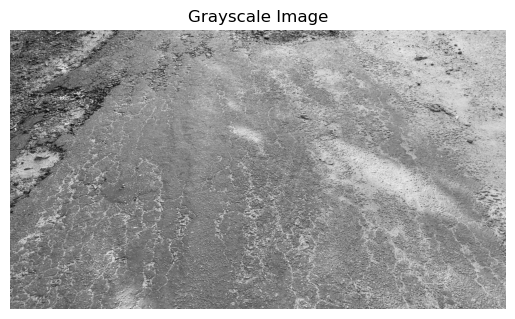

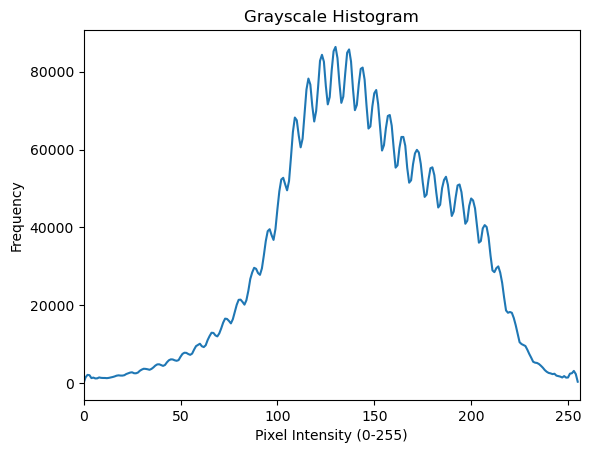

In [1]:
import cv2
import matplotlib.pyplot as plt

image_path = "frame_0091.jpg"   
img = cv2.imread(image_path)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure()
plt.title("Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

plt.figure()
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.plot(hist)
plt.xlim([0, 256])
plt.show()

##### Analyse 

After converting the image to grayscale and analyzing its histogram, we can clearly justify the absence of salt-and-pepper noise.

Salt-and-pepper noise is impulse noise characterized by:

Random black pixels (intensity = 0) → “pepper”
Random white pixels (intensity = 255) → “salt”

If salt-and-pepper noise were present, the histogram would show:
Very sharp spikes at 0
Very sharp spikes at 255
These spikes would be significantly higher than neighboring intensity values.
Because many pixels would be forced to extreme values.

From the plotted grayscale histogram:
The distribution is smooth and continuous
Pixel intensities are mainly concentrated in the mid-range (120–150)
There are no abnormal peaks at intensity 0
There are no abnormal peaks at intensity 255
The curve gradually increases and decreases without impulse spikes
This is strong statistical evidence that there are no extreme impulse values dominating the image.

##### Gaussian noise characteristics:

Affects pixels with small random variations
Produces a bell-shaped distribution
Does NOT create extreme isolated spikes
Histogram appears smooth and continuous

Our histogram matches this behavior:
Broad, smooth distribution
No isolated intensity impulses
Natural spread around the mean brightness

#### Mathematical/Statistical Proof Concept

Salt-and-pepper noise increases probability mass at:
 P (I = 0)
 P (I = 255)
 
 if present, we would mathematically observe:
       P (0) >> P(1),P(2),....
       P (255) >> P(254),P(253),.....
 
 But in our grayscale histogram:
    P(0) ≈ 0
    P(255) ≈ 0 
   No abnormal boundary peaks exist 

Thus:
No impulse dominated distribution --> No salt and pepper noise 

###### In conclusion

The grayscale histogram shows a smooth, continuous intensity distribution without sharp spikes at 0 or 255.

Since salt-and-pepper noise produces distinct extreme intensity spikes, and such spikes are absent in this histogram, we conclude with statistical and visual proof that:

The image does not contain salt-and-pepper noise.
The noise present is consistent with Gaussian noise characteristics.


   
 
 

In [2]:
import cv2
import numpy as np

img = cv2.imread("frame_0091.jpg" )
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print('Datatype:',img.dtype,
      '\nDimensions:',img.shape)

total_pixels = gray.size

# Count extreme pixels
num_zero = np.sum(gray == 0)
num_255 = np.sum(gray == 255)

# Percentage
percentage_extreme = (num_zero + num_255) / total_pixels * 100

print("Total Pixels:", total_pixels)
print("Pixels at 0:", num_zero)
print("Pixels at 255:", num_255)
print("Extreme Pixel Percentage: {:.4f}%".format(percentage_extreme))

# Decision
if percentage_extreme > 1:
    print("Salt-and-pepper noise likely PRESENT")
else:
    print("Salt-and-pepper noise likely NOT PRESENT")

Datatype: uint8 
Dimensions: (2160, 3840, 3)
Total Pixels: 8294400
Pixels at 0: 77
Pixels at 255: 388
Extreme Pixel Percentage: 0.0056%
Salt-and-pepper noise likely NOT PRESENT


Logic:

Salt-and-pepper noise artificially increases the number of extreme pixels (0 and 255).

If:

Pixels at 0 + Pixels at 255
______________________________  > 1% (roughly)
Total Pixels

Then salt-and-pepper noise is likely present.

This picture has 3840px width and 2160px height, so the total pixel of the image is 8294400

Pixel at 0 is equal to 77
and pixel at 255 is 388

The logic behind salt and papper is, 
(Pixel at 0 + pixel at 255 / total pixel * 100) < 1 

if it is less than 1 
salt and papper noise not likely present else likely present.

By considering above picture:
(77 + 388) / 8294400 * 100 = 0.0056
which is less than 1,
so we can come to a conclusion this picture not likely to have salt and papper noise.


